# MountainCar

INTEGRANTES:

1. Galvan Porcel Joel.
2. Valda Plaza Camila Monserrat.
3. Vasquez Caiza Juan Marcelo.
4. Yupari Figueroa Rosa Isela.

GRUPO: #6

##  Descripción
Este notebook implementa un agente de **Reinforcement Learning** que aprende a resolver el juego MountainCar usando:
- **Tabla de valores Q(s,a)**: Almacena qué tan buena es cada acción en cada estado
- **Exploración → Explotación**: Primero prueba al azar (80%), luego usa lo aprendido (5%)
- **Softmax**: Permite usar diferentes estrategias ganadoras (no repetir siempre lo mismo)

### Importación de librerías y configuración inicial

Se utiliza **gymnasium** para crear y manejar entornos de simulación, **numpy** para el manejo de arreglos numéricos, y **matplotlib** para la visualización de resultados mediante gráficos.  
También se importa **pickle** para guardar o cargar datos entrenados y **tqdm** para mostrar barras de progreso durante la ejecución de ciclos largos.  
Además, se configura el estilo de los gráficos con un tema oscuro y se activa la visualización directa en el cuaderno mediante `%matplotlib inline`.  
Finalmente, se establece una semilla aleatoria con `np.random.seed(42)` para asegurar que los resultados sean reproducibles en cada ejecución.

In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import pickle
from tqdm import tqdm

plt.style.use('seaborn-v0_8-darkgrid')
%matplotlib inline
np.random.seed(42)

## Clase del Agente

**¿Qué hace?**  
El agente es el “cerebro” que aprende a jugar. Tiene una **tabla de valores (Q-table)** donde guarda:
- Para cada situación (posición + velocidad del auto)
- Qué acción es mejor (izquierda, nada, derecha)
- Un número que indica qué tan buena es esa acción  

La clase `AgenteTablaSimple` implementa este agente de aprendizaje por refuerzo, que toma decisiones basadas en los valores que va aprendiendo en su tabla.  
Convierte los estados continuos del entorno en valores discretos (bins) para poder almacenarlos fácilmente, ya que es casi imposible volver exactamente a la misma posición o velocidad en cada episodio.  

El agente puede elegir sus acciones mediante dos estrategias:
- **Epsilon-Greedy**, que mezcla exploración (acciones aleatorias) y explotación (usar lo aprendido).  
- **Softmax**, que selecciona acciones probabilísticamente según su valor, manteniendo cierta diversidad.

También se usa una **tasa de aprendizaje adaptativa**, que disminuye cuando una acción-estado ha sido visitada muchas veces, reduciendo la importancia de lo ya aprendido y fomentando la exploración de nuevas estrategias.  
Finalmente, el parámetro `epsilon` se reduce gradualmente para que el agente explore menos y se concentre en las mejores decisiones aprendidas.


In [ ]:
class AgenteTablaSimple:
    """Agente con aprendizaje por tabla de valores (Q-table) y selección de acciones mediante Softmax o Epsilon-Greedy."""

    def __init__(self, temperatura=0.1, n_bins=12):
        # Definimos las posibles acciones: moverse a la izquierda, quedarse o moverse a la derecha
        self.acciones = [-1.0, 0.0, 1.0]
        # Diccionario que guarda los valores Q(s,a) aprendidos
        self.tabla_valores = {}
        # Diccionario para contar cuántas veces se ha visitado cada par (estado, acción)
        self.visitas = {}
        # Parámetro de exploración inicial (probabilidad de tomar una acción aleatoria)
        self.epsilon = 0.8
        # Temperatura para la función Softmax (controla la aleatoriedad)
        self.temperatura = temperatura
        # Número de divisiones o "bins" para discretizar los estados continuos
        self.n_bins = n_bins

    def estado_a_clave(self, estado):
        """Convierte un estado continuo (posición, velocidad) en una clave discreta para la tabla."""
        pos, vel = estado
        # Discretización de posición y velocidad en rangos enteros
        pos_bin = int((pos + 1.2) / 1.8 * self.n_bins)
        vel_bin = int((vel + 0.07) / 0.14 * self.n_bins)
        # Asegurar que los valores discretizados estén dentro de los límites
        pos_bin = max(0, min(self.n_bins - 1, pos_bin))
        vel_bin = max(0, min(self.n_bins - 1, vel_bin))
        return (pos_bin, vel_bin)

    def obtener_valor(self, estado, accion_idx):
        """Devuelve el valor Q(s,a) para un estado y acción dados. Si no existe, retorna 0.0."""
        clave = self.estado_a_clave(estado)
        return self.tabla_valores.get((clave, accion_idx), 0.0)

    def _softmax_accion(self, valores):
        """Selecciona una acción de forma probabilística usando la función Softmax."""
        # Normaliza los valores para evitar overflow numérico
        valores_norm = valores - np.max(valores)
        exp_valores = np.exp(valores_norm / self.temperatura)
        probabilidades = exp_valores / np.sum(exp_valores)
        # Devuelve un índice de acción según la probabilidad calculada
        return np.random.choice(3, p=probabilidades)

    def elegir_accion(self, estado, usar_softmax=False):
        """Elige una acción usando la política epsilon-greedy o Softmax."""
        # Con probabilidad epsilon se elige una acción aleatoria (exploración)
        if np.random.random() < self.epsilon:
            return np.random.randint(3)

        # Calcula los valores Q(s,a) para las tres posibles acciones
        valores = np.array([self.obtener_valor(estado, i) for i in range(3)])

        # Selecciona la acción mediante Softmax o el valor máximo (Greedy)
        if usar_softmax and self.temperatura > 0:
            return self._softmax_accion(valores)
        #con el valor mas alto en esa posicion y se complete el juego lo mas rapido
        return np.argmax(valores)

    def actualizar_valor(self, estado, accion_idx, recompensa):
        """Actualiza el valor Q(s,a) con una tasa de aprendizaje adaptativa."""
        clave = self.estado_a_clave(estado)
        key = (clave, accion_idx)

        # Aumenta el contador de visitas para este par (estado, acción)
        self.visitas[key] = self.visitas.get(key, 0) + 1

        # Calcula una tasa de aprendizaje adaptativa: más baja si ya fue visitado muchas veces
        tasa = 1.0 / (1.0 + self.visitas[key] * 0.1)

        # Actualiza el valor promedio móvil de Q(s,a)
        valor_actual = self.tabla_valores.get(key, 0.0)
        self.tabla_valores[key] = valor_actual + tasa * (recompensa - valor_actual)

    def reducir_exploracion(self):
        """Reduce gradualmente la probabilidad de exploración (epsilon)."""
        self.epsilon = max(0.05, self.epsilon * 0.993)


## Funciones de Recompensas

**¿Qué hace?**  
Estas funciones definen el **sistema de premios y castigos** que guían el aprendizaje del agente, ayudándole a entender qué acciones son buenas o malas durante el entrenamiento.  

El sistema se basa en los **cambios de altura** del automóvil dentro del entorno *MountainCar* de Gymnasium, incentivando los movimientos que acerquen al agente a la cima de la montaña (meta).  

**Recompensas definidas:**
- **Sube:** +100 puntos × la diferencia de altura  
- **Se queda quieto:** −15 puntos  
- **Baja:** −30 puntos × la diferencia de altura  
- **Cerca de la meta:** +50 puntos de bonus  
- **Llega a la meta:** +500 puntos de *mega bonus*  

Además, se combina la recompensa por movimiento con los bonos adicionales, y se impone un **límite mínimo de -40 puntos** para evitar valores negativos infinitos que pueden desestabilizar el aprendizaje.  
De esta forma, el agente aprende a **maximizar la recompensa total** moviéndose hacia adelante y subiendo la montaña de forma más eficiente.


In [ ]:
def calcular_recompensa_movimiento(altura_nueva, altura_ant, altura_max):
    """Calcula la recompensa según el cambio de altura del auto."""
    diferencia = altura_nueva - altura_ant

    # Si sube, recibe una recompensa proporcional al avance
    if diferencia > 0.001:
        return 100 * diferencia

    # Si se mantiene en la misma posición, recibe un castigo leve
    elif abs(diferencia) <= 0.001:
        return -15

    # Si baja, recibe un castigo más fuerte
    else:
        recompensa = -30 * abs(diferencia)
        # Si baja desde cerca del punto más alto, se castiga aún más
        if altura_ant >= altura_max - 0.05:
            recompensa -= 10
        return recompensa


def calcular_bonus(altura_nueva, terminated):
    """Calcula bonos adicionales por proximidad o llegada a la meta."""
    bonus = 0
    # Bonus si se acerca a la cima (meta aproximada del entorno)
    if altura_nueva > 0.35:  # En MountainCar, el rango de posición va de -1.2 a 0.6
        bonus += 50
    # Mega bonus si logra llegar completamente a la meta
    if terminated:
        bonus += 500
    return bonus


def calcular_recompensa_total(altura_nueva, altura_ant, altura_max, terminated):
    """Combina las recompensas parciales en una recompensa total controlada."""
    r_movimiento = calcular_recompensa_movimiento(altura_nueva, altura_ant, altura_max)
    r_bonus = calcular_bonus(altura_nueva, terminated)

    # Suma total de recompensas
    recompensa_total = r_movimiento + r_bonus

    # Límite inferior para evitar valores excesivamente negativos
    return max(recompensa_total, -40)


## Funciones de Entrenamiento

**¿Qué hace?**  
Estas funciones controlan el proceso de entrenamiento del agente en el entorno **MountainCarContinuous-v0**.  
El agente juega muchos episodios y en cada uno:
1. El auto intenta llegar a la cima de la montaña.
2. Se calculan recompensas según su progreso (altura y velocidad).
3. El agente actualiza su **tabla de valores (Q-table)**, aprendiendo qué acciones son mejores.
4. Gradualmente **reduce su exploración** (de probar acciones nuevas a usar lo aprendido).
5. Se muestran métricas de progreso como tasa de éxito, altura promedio y recompensa media.
6. Finalmente, el modelo entrenado se guarda en un archivo (`modelo_tabla.pkl`).


In [ ]:
# La tabla de valores es la función de valor (Q-table)
# env es el entorno del juego (MountainCarContinuous)

def ejecutar_episodio(env, agente):
    """
    Ejecuta un episodio completo de entrenamiento.
    El agente toma decisiones, recibe recompensas y actualiza su tabla Q.
    """
    estado, _ = env.reset()  # Reinicia el entorno y obtiene el estado inicial
    recompensa_total = 0
    exito = False  # Indicador de si alcanzó la meta
    altura_max = altura_ant = estado[0]  # El índice 0 representa la posición del auto
    pasos = 0
    
    # Máximo de 300 pasos por episodio que puede ser cambiado
    while pasos < 300:
        # El agente elige una acción según su política (exploración o explotación)
        accion_idx = agente.elegir_accion(estado)
        
        # Ejecuta la acción en el entorno y obtiene los resultados
        siguiente, recompensa_env, terminated, truncated, _ = env.step([agente.acciones[accion_idx]])
        
        # Actualiza métricas de altura
        altura_nueva = siguiente[0]
        altura_max = max(altura_max, altura_nueva)
        
        # Calcula una recompensa personalizada basada en el progreso del auto
        r_aprendizaje = calcular_recompensa_total(altura_nueva, altura_ant, altura_max, terminated)
        
        # Actualiza la tabla Q con la nueva información aprendida
        agente.actualizar_valor(estado, accion_idx, r_aprendizaje)
        
        # Actualiza el estado y suma recompensas
        estado = siguiente
        altura_ant = altura_nueva
        recompensa_total += recompensa_env
        pasos += 1
        
        # Si el auto llega a la meta o el episodio termina, salir del bucle
        if terminated or truncated:
            exito = terminated
            break
    
    return recompensa_total, exito, altura_max


def imprimir_progreso(ep, n_episodios, exitos, alturas, recompensas, agente):
    """
    Muestra estadísticas de entrenamiento cada 100 episodios:
    tasa de éxito, altura promedio, recompensa promedio y nivel de exploración.
    """
    tasa = np.mean(exitos[-100:]) * 100
    altura_prom = np.mean(alturas[-100:])
    recompensa_prom = np.mean(recompensas[-100:])
    
    tqdm.write(f"\n{'='*80}")
    tqdm.write(f"Episodio {ep+1}/{n_episodios}")
    tqdm.write(f"Tasa de éxito: {tasa:.1f}%")
    tqdm.write(f"Altura promedio: {altura_prom:.3f}")
    tqdm.write(f"Recompensa promedio: {recompensa_prom:.2f}")
    tqdm.write(f"Exploración: {agente.epsilon*100:.1f}%")
    tqdm.write(f"Valores aprendidos (estados almacenados): {len(agente.tabla_valores)}")
    tqdm.write(f"{'='*80}\n")


def guardar_modelo(agente, tasa_final, archivo='modelo_tabla.pkl'):
    """
    Guarda el modelo entrenado (tabla de valores y parámetros del agente)
    en un archivo pickle para poder reutilizarlo.
    """
    with open(archivo, 'wb') as f:
        pickle.dump({
            'tabla_valores': agente.tabla_valores,
            'acciones': agente.acciones,
            'n_bins': agente.n_bins,
            'tasa_exito': tasa_final
        }, f)


def entrenar_con_tabla(n_episodios=1200, verbose=True):
    """
    Función principal de entrenamiento.
    Crea el entorno y el agente, ejecuta los episodios de aprendizaje
    y guarda el modelo final entrenado.
    """
    env = gym.make("MountainCarContinuous-v0")
    agente = AgenteTablaSimple()
    
    recompensas, exitos, alturas = [], [], []
    
    if verbose:
        print("Entrenamiento con Tabla de Valores")
        print("Estrategia: Explorar → Aprender → Explotar\n")
    
    # Bucle principal de entrenamiento
    for ep in tqdm(range(n_episodios), desc="Entrenando", unit="ep", ncols=100):
        # Ejecutar un episodio y obtener resultados
        r, exito, h = ejecutar_episodio(env, agente)
        
        # Guardar métricas para análisis posterior
        recompensas.append(r)
        exitos.append(1 if exito else 0)
        alturas.append(h)
        
        # Reducir la tasa de exploración (menos aleatoriedad con el tiempo)
        agente.reducir_exploracion()
        
        # Mostrar estadísticas cada 100 episodios
        if verbose and (ep + 1) % 100 == 0:
            imprimir_progreso(ep, n_episodios, exitos, alturas, recompensas, agente)
    
    env.close()
    
    # Calcular la tasa final de éxito
    tasa_final = np.mean(exitos[-100:]) * 100
    guardar_modelo(agente, tasa_final)
    
    # Mostrar resumen final
    if verbose:
        print(f"\n{'='*80}")
        print("ENTRENAMIENTO COMPLETADO")
        print(f"{'='*80}")
        print(f"Modelo guardado: modelo_tabla.pkl")
        print(f"Tasa de éxito final: {tasa_final:.1f}%")
        print(f"Éxitos totales: {sum(exitos)}/{len(exitos)} ({sum(exitos)/len(exitos)*100:.1f}%)")
        print(f"Valores aprendidos: {len(agente.tabla_valores)}")
        print(f"{'='*80}\n")
    
    return recompensas, exitos, alturas, agente


## Funciones de Juego

**¿Qué hace?**  
Estas funciones permiten **usar el modelo ya entrenado para jugar**, sin seguir aprendiendo.  
El agente se enfrenta nuevamente al entorno **MountainCarContinuous-v0**, aplicando lo que aprendió en el entrenamiento.

**Modos de juego:**
- **Con diversidad (Softmax):** el agente elige acciones de forma probabilística, explorando distintas estrategias (más realista e interesante).  
- **Sin diversidad (Determinista):** el agente siempre elige la mejor acción posible (comportamiento más estable pero repetitivo).

Además, se muestra un resumen final con métricas como tasa de éxito, recompensas, pasos promedio y altura máxima alcanzada.


In [ ]:
def cargar_modelo(archivo='modelo_tabla.pkl', temperatura=0.3):
    """
    Carga el modelo entrenado desde un archivo .pkl previamente guardado.
    Este modelo contiene la tabla de valores aprendida por el agente.
    """
    # Abre el archivo en modo lectura binaria para cargar los datos
    with open(archivo, 'rb') as f:
        datos = pickle.load(f)
    
    # Se crea un nuevo agente con la temperatura indicada (para el Softmax)
    agente = AgenteTablaSimple(temperatura=temperatura)
    
    # Se restauran los parámetros y la tabla Q aprendida del modelo guardado
    agente.tabla_valores = datos['tabla_valores']  # Valores aprendidos Q(s,a)
    agente.acciones = datos['acciones']            # Lista de posibles acciones [-1, 0, 1]
    agente.n_bins = datos['n_bins']                # Número de divisiones del espacio de estados
    
    # Se desactiva la exploración, ya que el agente no está aprendiendo, solo jugando
    agente.epsilon = 0.0  
    
    # Se devuelve el agente ya cargado junto con la información adicional del modelo
    return agente, datos


def jugar_episodio(env, agente, usar_softmax):
    """
    Ejecuta un solo episodio de juego (una partida completa).
    El agente juega sin aprender, usando la tabla Q que ya tiene cargada.
    """
    # Reinicia el entorno para comenzar desde el inicio
    estado, _ = env.reset()
    
    # Inicializa métricas de seguimiento
    recompensa_total = 0      # Acumulará todas las recompensas del episodio
    altura_max = estado[0]    # Guarda la altura inicial (posición horizontal)
    pasos = 0                 # Contador de pasos dados
    
    # El agente puede realizar un máximo de 300 pasos por episodio es adaptable
    while pasos < 300:
        # Elegir una acción usando la política aprendida
        # usar_softmax=True → elige probabilísticamente (diversidad)
        accion_idx = agente.elegir_accion(estado, usar_softmax=usar_softmax)
        
        # Ejecutar la acción seleccionada en el entorno
        # env.step devuelve:
        #   - nuevo estado del entorno
        #   - recompensa obtenida
        #   - terminated (si llegó a la meta)
        #   - truncated (si terminó el tiempo máximo)
        estado, recompensa, terminated, truncated, _ = env.step([agente.acciones[accion_idx]])
        
        # Actualiza la altura máxima alcanzada hasta el momento
        altura_max = max(altura_max, estado[0])
        
        # Suma la recompensa de este paso al total acumulado
        recompensa_total += recompensa
        
        # Incrementa el contador de pasos
        pasos += 1
        
        # Si llega a la meta o el episodio termina, se detiene
        if terminated or truncated:
            return recompensa_total, pasos, terminated, altura_max
    
    # Si no alcanzó la meta tras los pasos, devuelve los resultados acumulados
    return recompensa_total, pasos, False, altura_max


def imprimir_resumen_juego(resultados_e, resultados_r, resultados_p, alturas, diversidad):
    """
    Muestra un resumen con estadísticas de los episodios jugados:
    - Tasa de éxito (porcentaje de veces que el agente llega a la meta)
    - Recompensa media y su desviación
    - Promedio de pasos y altura máxima alcanzada
    """
    # Calcula la tasa de éxito (% de episodios ganados)
    tasa = np.mean(resultados_e) * 100
    
    print(f"\n{'='*60}")
    print(f"RESUMEN:")
    print(f"{'='*60}")
    print(f"Tasa de éxito: {tasa:.1f}%")  # Éxito global
    print(f"Recompensa promedio: {np.mean(resultados_r):.2f} ± {np.std(resultados_r):.2f}")  # Media ± Desviación
    print(f"Pasos promedio: {np.mean(resultados_p):.1f} ± {np.std(resultados_p):.1f}")        # Promedio de pasos
    print(f"Altura promedio: {np.mean(alturas):.3f}")                                        # Altura promedio alcanzada
    print(f"Éxitos: {sum(resultados_e)}/{len(resultados_e)}")                                # Total de éxitos logrados
    
    # Si se jugó en modo “diversidad”, muestra la variabilidad de estrategias
    if diversidad:
        print(f"\nVariación en estrategias: {np.std(resultados_p):.1f} pasos")
    
    print(f"{'='*60}\n")


def jugar_con_tabla(archivo='modelo_tabla.pkl', n_episodios=5, mostrar=True, 
                    diversidad=True, temperatura=0.3):
    """
    Función principal que controla el proceso de juego:
    - Carga el modelo entrenado
    - Ejecuta varios episodios (por defecto, 5)
    - Muestra el progreso y un resumen final de desempeño
    """
    # Cargar el modelo entrenado previamente
    agente, datos = cargar_modelo(archivo, temperatura)

    # Mostrar información básica del modelo cargado
    print(f"Modelo cargado: {archivo}")
    print(f"Tasa de éxito en entrenamiento: {datos['tasa_exito']:.1f}%")
    print(f"Valores en tabla: {len(agente.tabla_valores)}")  # Cantidad de pares (estado, acción) aprendidos
    print(f"{'Modo: Softmax (diversidad)' if diversidad else 'Modo: Determinista'}")
    
    # Si el modo “mostrar” está activo, el entorno se visualizará gráficamente
    if mostrar:
        print(f"Renderizando (puede ser lento)...")
    
    print(f"\n{'='*60}")
    print("🎮 JUGANDO...")
    print(f"{'='*60}\n")
    
    # Inicializa listas para registrar estadísticas de los juegos
    resultados_r, resultados_p, resultados_e, alturas = [], [], [], []
    
    # tqdm muestra una barra de progreso visual en el notebook
    iterator = tqdm(range(n_episodios), desc="🎮 Jugando", disable=mostrar)
    
    # Ejecutar varios episodios de juego
    for ep in iterator:
        # Crea un nuevo entorno para cada episodio
        env = gym.make("MountainCarContinuous-v0", 
                       render_mode="human" if mostrar else None)
        
        # Ejecuta un episodio completo (una partida)
        r, p, exito, h = jugar_episodio(env, agente, diversidad)
        
        # Cierra el entorno al finalizar el episodio
        env.close()
        
        # Guarda los resultados de este episodio
        resultados_r.append(r)           # Recompensa total
        resultados_p.append(p)           # Pasos realizados
        resultados_e.append(1 if exito else 0)  # 1 si tuvo éxito, 0 si no
        alturas.append(h)                # Altura máxima alcanzada
        
        # Muestra el resultado del episodio
        msg = f"Ep {ep+1}: {'✅ ÉXITO' if exito else '❌ Falló'} - Pasos={p}, Altura={h:.3f}"
        if mostrar:
            print(msg)
        else:
            tqdm.write(msg)
    
    # Al finalizar todos los episodios, imprime un resumen global del desempeño
    imprimir_resumen_juego(resultados_e, resultados_r, resultados_p, alturas, diversidad)
    
    # Devuelve las métricas finales (recompensas, pasos y éxitos)
    return resultados_r, resultados_p, resultados_e


## Funciones de Visualización
Generacion de gráficas para entender cómo aprende el agente:

In [6]:
def suavizar(datos, ventana=50):
    # Promedio móvil para suavizar datos
    if len(datos) < ventana:
        return datos
    return np.convolve(datos, np.ones(ventana)/ventana, mode='valid')

def graficar_entrenamiento(recompensas, exitos, max_alturas, agente_entrenado):
    # Genera gráficas del entrenamiento
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.suptitle('Aprendizaje con Tabla de Valores', fontsize=15, fontweight='bold')
    
    # Pre-calcular
    recompensas_suav = suavizar(recompensas, 50)
    alturas_suav = suavizar(max_alturas, 50)
    tasa_exito = np.convolve(exitos, np.ones(50)/50, mode='valid') * 100
    
    # 1. Recompensas
    ax1 = axes[0, 0]
    ax1.plot(recompensas_suav, color='darkblue', linewidth=2)
    ax1.set_xlabel('Episodio', fontsize=10)
    ax1.set_ylabel('Recompensa', fontsize=10)
    ax1.set_title('Recompensas por Episodio', fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # 2. Tasa de éxito
    ax2 = axes[0, 1]
    ax2.plot(tasa_exito, color='green', linewidth=2)
    ax2.fill_between(range(len(tasa_exito)), tasa_exito, alpha=0.3, color='green')
    ax2.set_xlabel('Episodio', fontsize=10)
    ax2.set_ylabel('Tasa de Éxito (%)', fontsize=10)
    ax2.set_title('Evolución del Éxito', fontsize=11)
    ax2.set_ylim([0, 105])
    ax2.grid(True, alpha=0.3)
    
    # 3. Altura
    ax3 = axes[1, 0]
    ax3.plot(alturas_suav, color='orange', linewidth=2)
    ax3.axhline(y=0.45, color='red', linestyle='--', label='Meta', linewidth=2)
    ax3.set_xlabel('Episodio', fontsize=10)
    ax3.set_ylabel('Altura Máxima', fontsize=10)
    ax3.set_title('Progreso en Altura', fontsize=11)
    ax3.legend(fontsize=9)
    ax3.grid(True, alpha=0.3)
    
    # 4. Estadísticas
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    tasa_final = np.mean(exitos[-100:]) * 100
    stats = f"""
   RESULTADOS FINALES
{'='*35}

Últimos 100 episodios:
    Éxito: {tasa_final:.1f}%
    Altura: {np.mean(max_alturas[-100:]):.3f}

Global:
    Éxitos: {sum(exitos)}/{len(exitos)}
    Tasa: {sum(exitos)/len(exitos)*100:.1f}%

Aprendizaje:
    Valores: {len(agente_entrenado.tabla_valores)}
    Tabla de valores
"""
    
    ax4.text(0.05, 0.95, stats, transform=ax4.transAxes,
             fontsize=11, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.5))
    
    plt.tight_layout()
    plt.show()

def graficar_evaluacion(eval_r, eval_e):
    # Genera gráficas de evaluación
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Barras
    ax1.bar(range(1, len(eval_r)+1), eval_r,
            color=['green' if s else 'red' for s in eval_e], alpha=0.7)
    ax1.axhline(y=np.mean(eval_r), color='blue', linestyle='--',
                linewidth=2, label=f'Promedio: {np.mean(eval_r):.2f}')
    ax1.set_xlabel('Episodio')
    ax1.set_ylabel('Recompensa')
    ax1.set_title('Evaluación con Diversidad')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Pie
    exitos_c = sum(eval_e)
    fallos_c = len(eval_e) - exitos_c
    ax2.pie([exitos_c, fallos_c],
            labels=[f'Éxito\n{exitos_c}', f'Fallo\n{fallos_c}'],
            colors=['green', 'red'],
            autopct='%1.1f%%',
            startangle=90,
            textprops={'fontsize': 14, 'fontweight': 'bold'})
    ax2.set_title(f'Tasa de Éxito: {exitos_c/len(eval_e)*100:.1f}%')
    
    plt.tight_layout()
    plt.show()
    
    # Clasificación
    tasa = exitos_c / len(eval_e) * 100
    if tasa >= 70:
        rating = "EXCELENTE"
    elif tasa >= 50:
        rating = "BUENO"
    elif tasa >= 30:
        rating = "REGULAR"
    else:
        rating = "NECESITA MÁS ENTRENAMIENTO"
    
    print(f"\n{'='*60}")
    print(f"CLASIFICACIÓN: {rating}")
    print(f"{'='*60}")

## Entrenar el Modelo

**¿Qué hace?**  
Esta sección ejecuta el entrenamiento del agente durante **los episodios**.  
Durante el proceso se puede observar:

- Una **barra de progreso en tiempo real** mostrando el avance del entrenamiento.
- **Estadísticas cada 100 episodios**, incluyendo tasa de éxito, altura promedio y recompensa promedio.
- **Guardado automático del modelo** entrenado en `modelo_tabla.pkl` para poder usarlo posteriormente sin necesidad de volver a entrenar.


In [ ]:
# Entrenar el agente usando la tabla de valores (Q-table)
# Se especifica el número de episodios y que se muestre información detallada

recompensas, exitos, max_alturas, agente_entrenado = entrenar_con_tabla(
    n_episodios=1200,  # Número total de episodios de entrenamiento
    verbose=True        # Mostrar estadísticas y progreso durante el entrenamiento
)

# recompensas       → Lista con la recompensa total obtenida en cada episodio
# exitos            → Lista con 1 si el agente alcanzó la meta en ese episodio, 0 si no
# max_alturas       → Lista con la altura máxima alcanzada por el auto en cada episodio
# agente_entrenado  → Objeto del agente con la tabla de valores ya actualizada y lista para jugar


Entrenamiento con Tabla de Valores
Estrategia: Explorar → Aprender → Explotar



Entrenando:  10%|████▊                                          | 124/1200 [00:00<00:07, 140.28ep/s]


Episodio 100/1200
Tasa de éxito: 2.0%
Altura promedio: 0.044
Recompensa promedio: -20.51
Exploración: 39.6%
Valores aprendidos: 273



Entrenando:  18%|████████▎                                      | 211/1200 [00:01<00:06, 154.42ep/s]


Episodio 200/1200
Tasa de éxito: 42.0%
Altura promedio: 0.311
Recompensa promedio: 20.57
Exploración: 19.6%
Valores aprendidos: 281



...


Episodio 1000/1200
Tasa de éxito: 100.0%
Altura promedio: 0.468
Recompensa promedio: 85.92
Exploración: 5.0%
Valores aprendidos: 286



Entrenando:  95%|███████████████████████████████████████████▌  | 1137/1200 [00:05<00:00, 218.54ep/s]


Episodio 1100/1200
Tasa de éxito: 100.0%
Altura promedio: 0.467
Recompensa promedio: 85.97
Exploración: 5.0%
Valores aprendidos: 286



Entrenando: 100%|██████████████████████████████████████████████| 1200/1200 [00:05<00:00, 213.68ep/s]


Episodio 1200/1200
Tasa de éxito: 100.0%
Altura promedio: 0.469
Recompensa promedio: 85.61
Exploración: 5.0%
Valores aprendidos: 286


ENTRENAMIENTO COMPLETADO
Modelo guardado: modelo_tabla.pkl
Tasa de éxito final: 100.0%
Éxitos totales: 1033/1200 (86.1%)
Valores aprendidos: 286



## Visualizar Entrenamiento
Generacion de 4 gráficas que muestran el proceso de aprendizaje:
1. Cómo mejoran las recompensas
2. Cómo aumenta la tasa de éxito
3. Cómo sube más alto con el tiempo
4. Estadísticas finales del entrenamiento

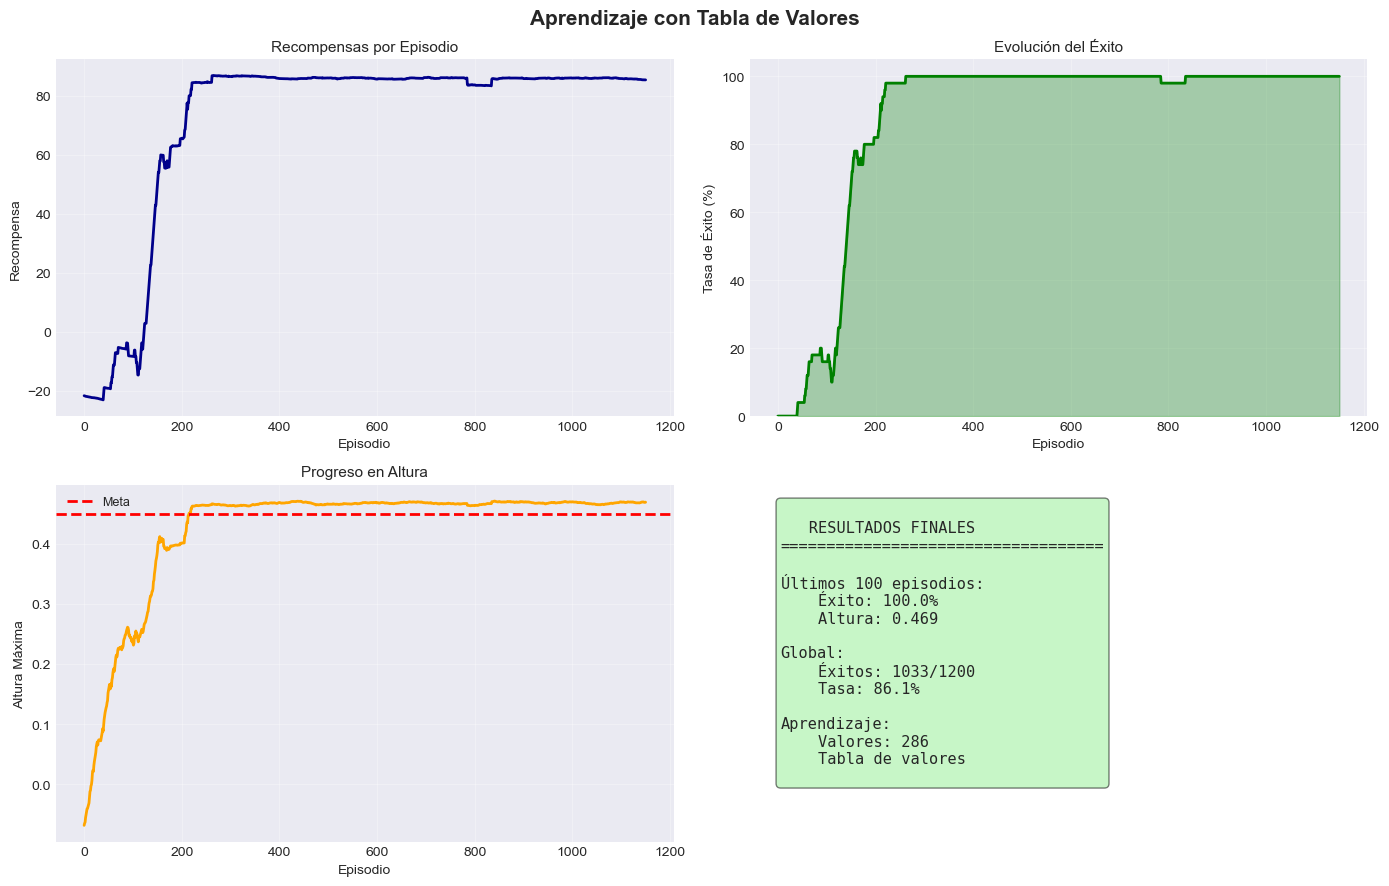

In [8]:
graficar_entrenamiento(recompensas, exitos, max_alturas, agente_entrenado)

## Jugar con el Modelo

**¿Qué hace?**  
Usa el modelo ya entrenado para jugar **ciertos episodios o los que uno requiera** con visualización del juego.  

Características de este bloque:
- Se muestra la **ventana del juego en acción**.
- Modo **Softmax activado**, lo que permite que el agente use **estrategias variadas** en cada episodio.
- La **temperatura** está en **0.3**, controlando la probabilidad de explorar diferentes acciones (moderada).
- Permite observar cómo el agente aplica lo aprendido en situaciones reales del entorno.


In [ ]:
# Ejecutar el juego usando el modelo entrenado
# Se selecciona diversidad (Softmax) para que el agente explore estrategias distintas
# Se muestran los episodios gráficamente en tiempo real

r, p, e = jugar_con_tabla(
    'modelo_tabla.pkl',  # Archivo del modelo entrenado
    n_episodios=10,      # Número de episodios que se van a jugar
    mostrar=True,        # Mostrar la ventana del juego (renderizar)
    diversidad=True,     # Activar Softmax para elegir acciones con cierta aleatoriedad
    temperatura=0.3      # Controla la aleatoriedad del Softmax (0.3 → variación moderada)
)

# r → Lista de recompensas totales obtenidas en cada episodio
# p → Lista de pasos realizados en cada episodio
# e → Lista indicando si el agente tuvo éxito (1) o no (0) en cada episodio


Modelo cargado: modelo_tabla.pkl
Tasa de éxito en entrenamiento: 100.0%
Valores en tabla: 286
Modo: Softmax (diversidad)
Renderizando (puede ser lento)...

🎮 JUGANDO...

Ep 1: ❌ Falló - Pasos=300, Altura=0.007
Ep 2: ❌ Falló - Pasos=300, Altura=-0.008
Ep 3: ❌ Falló - Pasos=300, Altura=-0.046
Ep 4: ❌ Falló - Pasos=300, Altura=0.442
Ep 5: ❌ Falló - Pasos=300, Altura=0.063
Ep 6: ❌ Falló - Pasos=300, Altura=-0.067
Ep 7: ❌ Falló - Pasos=300, Altura=-0.080
Ep 8: ❌ Falló - Pasos=300, Altura=-0.051
Ep 9: ✅ ÉXITO - Pasos=279, Altura=0.465
Ep 10: ❌ Falló - Pasos=300, Altura=0.127

RESUMEN:
Tasa de éxito: 10.0%
Recompensa: -12.82 ± 30.24
Pasos: 297.9 ± 6.3
Altura: 0.085
Éxitos: 1/10

 Variación en estrategias: 6.3 pasos



## Comparación: Diversidad vs Determinista

**¿Qué hace?**  
Este bloque compara los dos modos de juego usando el modelo entrenado:

**Con diversidad (Softmax):**
- El agente elige acciones probabilísticamente, explorando **diferentes estrategias** en cada episodio.
- Mayor **variación en el número de pasos**.
- Más interesante de observar.

**Sin diversidad (Determinista):**
- El agente siempre selecciona la **mejor acción aprendida**.
- Menor variación en el número de pasos.
- Comportamiento repetitivo pero eficiente.


Comparando modos...

CON DIVERSIDAD (Softmax)
Modelo cargado: modelo_tabla.pkl
Tasa de éxito en entrenamiento: 100.0%
Valores en tabla: 286
Modo: Softmax (diversidad)

🎮 JUGANDO...



🎮 Jugando:  50%|█████     | 5/10 [00:00<00:00, 40.42it/s]

Ep 1: ❌ Falló - Pasos=300, Altura=0.320
Ep 2: ❌ Falló - Pasos=300, Altura=-0.150
Ep 3: ✅ ÉXITO - Pasos=215, Altura=0.458
Ep 4: ❌ Falló - Pasos=300, Altura=0.026
Ep 5: ❌ Falló - Pasos=300, Altura=0.021


🎮 Jugando:  50%|█████     | 5/10 [00:00<00:00, 40.42it/s]

Ep 6: ❌ Falló - Pasos=300, Altura=0.331
Ep 7: ✅ ÉXITO - Pasos=225, Altura=0.473


...

Ep 1: ✅ ÉXITO - Pasos=166, Altura=0.453
Ep 2: ✅ ÉXITO - Pasos=162, Altura=0.465
Ep 3: ✅ ÉXITO - Pasos=151, Altura=0.464
Ep 4: ✅ ÉXITO - Pasos=152, Altura=0.466
Ep 5: ✅ ÉXITO - Pasos=150, Altura=0.479


🎮 Jugando:  90%|█████████ | 9/10 [00:00<00:00, 89.30it/s]

Ep 6: ✅ ÉXITO - Pasos=152, Altura=0.487
Ep 7: ✅ ÉXITO - Pasos=152, Altura=0.485
Ep 8: ✅ ÉXITO - Pasos=151, Altura=0.464
Ep 9: ✅ ÉXITO - Pasos=153, Altura=0.481


🎮 Jugando: 100%|██████████| 10/10 [00:00<00:00, 80.94it/s]


Ep 10: ✅ ÉXITO - Pasos=153, Altura=0.472

RESUMEN:
Tasa de éxito: 100.0%
Recompensa: 84.80 ± 0.69
Pasos: 154.2 ± 5.1
Altura: 0.472
Éxitos: 10/10



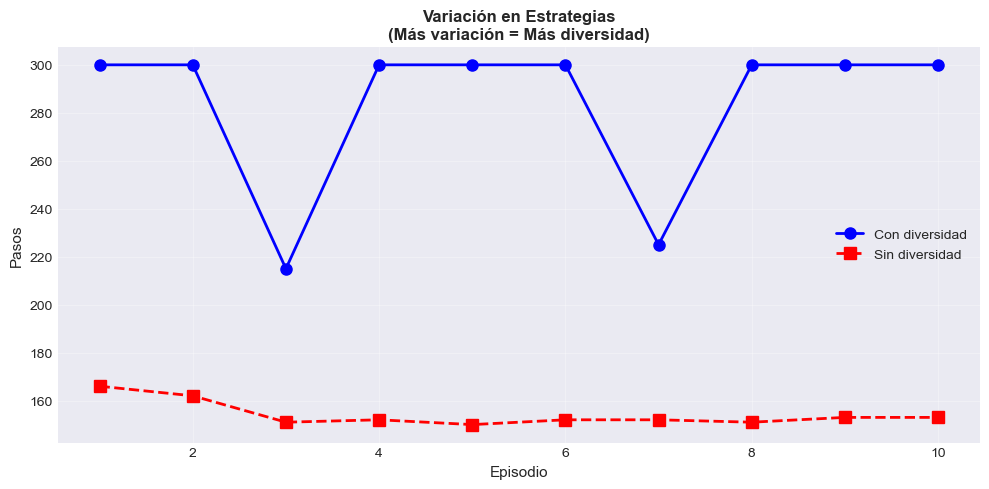


 Variación con diversidad: 32.1 pasos
 Variación sin diversidad: 5.1 pasos


In [10]:
print("Comparando modos...\n")

# Con diversidad
print("CON DIVERSIDAD (Softmax)")
r_div, p_div, e_div = jugar_con_tabla('modelo_tabla.pkl', n_episodios=10, 
                                       mostrar=False, diversidad=True, temperatura=0.3)

# Sin diversidad
print("\nSIN DIVERSIDAD (Determinista)")
r_det, p_det, e_det = jugar_con_tabla('modelo_tabla.pkl', n_episodios=10, 
                                       mostrar=False, diversidad=False)

# Gráfica comparativa
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
x = np.arange(1, 11)
ax.plot(x, p_div, 'o-', linewidth=2, markersize=8, label='Con diversidad', color='blue')
ax.plot(x, p_det, 's--', linewidth=2, markersize=8, label='Sin diversidad', color='red')
ax.set_xlabel('Episodio', fontsize=11)
ax.set_ylabel('Pasos', fontsize=11)
ax.set_title('Variación en Estrategias\n(Más variación = Más diversidad)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n Variación con diversidad: {np.std(p_div):.1f} pasos")
print(f" Variación sin diversidad: {np.std(p_det):.1f} pasos")